# TRB-only Clonotype Validation

This notebook quantifies:
1. How many cells are uniquely identified by TRB alone (CDR3 amino acid)
2. What percentage of cells would be **ambiguous** (same TRB, different TRA) — i.e., the fraction that TRB alone cannot resolve
3. How many TRB-defined clones are 'split' once TRA is added

**Conda environment:** `mrvi`

In [5]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [6]:
mpl.rcParams.update({
    'font.size': 12,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

In [7]:
PROJECT_ROOT = Path('../..')   # → GVHD_project_v2/

TCR_DATA_DIR          = PROJECT_ROOT / 'filtered_contig_annotations'
TCELL_ANN_PATH        = PROJECT_ROOT / 'adata_file' / 'tcell_ann_concat_Tcell_only_annotated.h5ad'
FIGURES_DIR           = PROJECT_ROOT / 'Figures'

Sample_list = [
    'R096_Tc17_up', 'R096_Tc17_low', 'RH01', 'RH02', 'RH03', 'RH04',
    'RH05', 'RH06', 'RH07', 'RH08', 'RH09', 'RH10', 'RH11', 'RH12',
    'RH13', 'RH14', 'UA01', 'UA02', 'UA03', 'UA04', 'UA05', 'UA06',
    'UA07', 'UA08', 'UA09', 'UA10', 'UA11', 'UA12', 'UA13', 'UA14',
    'UA15', 'UA19', 'UA20', 'UA21', 'UA22', 'UA23', 'UA24', 'UA26',
    'UA30', 'UA31', 'UA32', 'UA33', 'UA34', 'UA35', 'UA36', 'UA37',
    'UA38', 'UA39', 'UA40', 'UA41',
]

## 1. Load and filter contig data

Keep only: `is_cell=True`, `productive=True`, `high_confidence=True`.
For each cell, pick the chain with the highest UMI count as the representative TRB and TRA.

In [8]:
dfs = []
for sample in Sample_list:
    fpath = TCR_DATA_DIR / f'{sample}_contig.csv'
    if not fpath.exists():
        print(f'Missing: {fpath}')
        continue
    df = pd.read_csv(fpath)
    df['cell_id'] = sample + '_' + df['barcode']
    df['sample']  = sample
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
print(f'Total contigs loaded: {len(raw):,}')
print(f'Columns: {raw.columns.tolist()}')

Total contigs loaded: 100,503
Columns: ['barcode', 'is_cell', 'contig_id', 'high_confidence', 'length', 'chain', 'v_gene', 'd_gene', 'j_gene', 'c_gene', 'full_length', 'productive', 'cdr3', 'cdr3_nt', 'reads', 'umis', 'raw_clonotype_id', 'raw_consensus_id', 'cell_id', 'sample', 'fwr1', 'fwr1_nt', 'cdr1', 'cdr1_nt', 'fwr2', 'fwr2_nt', 'cdr2', 'cdr2_nt', 'fwr3', 'fwr3_nt', 'fwr4', 'fwr4_nt', 'exact_subclonotype_id']


In [9]:
# Filter to productive, high-confidence, is_cell rows
filt = raw[
    (raw['is_cell']        == True) &
    (raw['productive']     == True) &
    (raw['high_confidence']== True) &
    (raw['chain'].isin(['TRA', 'TRB']))
].copy()

# Drop rows without a CDR3 amino acid sequence
filt = filt.dropna(subset=['cdr3'])
filt = filt[filt['cdr3'].str.strip() != '']

print(f'Filtered contigs: {len(filt):,}')
print(filt['chain'].value_counts())

Filtered contigs: 98,538
chain
TRB    52097
TRA    46441
Name: count, dtype: int64


In [10]:
# Per cell, pick the representative chain (highest UMI)
# Sort by umis descending so the first row per (cell_id, chain) is the top chain
filt_sorted = filt.sort_values('umis', ascending=False)

trb = (filt_sorted[filt_sorted['chain'] == 'TRB']
       .groupby('cell_id', sort=False)
       .first()[['cdr3', 'v_gene', 'j_gene', 'sample']]
       .rename(columns={'cdr3': 'TRB_cdr3', 'v_gene': 'TRB_v', 'j_gene': 'TRB_j'}))

tra = (filt_sorted[filt_sorted['chain'] == 'TRA']
       .groupby('cell_id', sort=False)
       .first()[['cdr3', 'v_gene', 'j_gene']]
       .rename(columns={'cdr3': 'TRA_cdr3', 'v_gene': 'TRA_v', 'j_gene': 'TRA_j'}))

# Merge into one row per cell
cells = trb.join(tra, how='left')

print(f'\nTotal cells with TRB: {len(cells):,}')
print(f'Cells with both TRB and TRA: {cells["TRA_cdr3"].notna().sum():,}')
print(f'Cells with TRB only (no TRA detected): {cells["TRA_cdr3"].isna().sum():,}')


Total cells with TRB: 49,746
Cells with both TRB and TRA: 39,886
Cells with TRB only (no TRA detected): 9,860


## 1b. Restrict to annotated T cells

Load  and keep only the barcodes present in that object (38,539 cells that passed QC and annotation).

In [11]:
import anndata

tcell_ann = anndata.read_h5ad(TCELL_ANN_PATH)
tcell_barcodes = set(tcell_ann.obs.index)  # format: SampleID_barcode
print(f'Annotated T cells in h5ad: {len(tcell_barcodes):,}')

# Filter cells DataFrame to only annotated T cells
cells_all  = cells.copy()   # keep the full set for reference
cells      = cells[cells.index.isin(tcell_barcodes)].copy()
print(f'Cells with TRB — all contigs:         {len(cells_all):,}')
print(f'Cells with TRB — annotated T cells:   {len(cells):,}')
print(f'  of which also have TRA:             {cells["TRA_cdr3"].notna().sum():,}')

Annotated T cells in h5ad: 38,539
Cells with TRB — all contigs:         49,746
Cells with TRB — annotated T cells:   27,911
  of which also have TRA:             24,791


## 2. Clonotype definition — TRB-only vs TRB+TRA

In [ ]:
# Restrict to cells that have BOTH chains for a fair comparison
both = cells.dropna(subset=['TRA_cdr3']).copy()
print(f'Cells with both TRB and TRA (used for comparison): {len(both):,}')

# TRB-only clonotype = TRB CDR3 amino acid sequence
both['clone_TRB'] = both['TRB_cdr3']

# Full clonotype = TRB CDR3 + TRA CDR3 concatenated
both['clone_TRB_TRA'] = both['TRB_cdr3'] + '_' + both['TRA_cdr3']

Cells with both TRB and TRA (used for comparison): 24,791


In [13]:
n_cells      = len(both)
n_clones_TRB     = both['clone_TRB'].nunique()
n_clones_TRB_TRA = both['clone_TRB_TRA'].nunique()

print(f'Cells analysed:               {n_cells:>8,}')
print(f'Unique clones — TRB only:      {n_clones_TRB:>8,}')
print(f'Unique clones — TRB + TRA:     {n_clones_TRB_TRA:>8,}')
print(f'Additional clones gained by TRA: {n_clones_TRB_TRA - n_clones_TRB:>6,}')
print(f'% of full clones captured by TRB alone: {n_clones_TRB / n_clones_TRB_TRA * 100:.1f}%')

Cells analysed:                 24,791
Unique clones — TRB only:        12,573
Unique clones — TRB + TRA:       13,185
Additional clones gained by TRA:    612
% of full clones captured by TRB alone: 95.4%


## 3. Ambiguous cells — same TRB, different TRA

A TRB clone is **ambiguous** if cells within it carry different TRA sequences,
meaning TRB alone would merge distinct clonotypes.

In [14]:
# For each TRB clone, count how many distinct TRA CDR3s it contains
trb_clone_stats = (
    both.groupby('clone_TRB', observed=True)
    .agg(
        n_cells        = ('clone_TRB', 'size'),
        n_unique_TRA   = ('TRA_cdr3', 'nunique'),
        n_full_clones  = ('clone_TRB_TRA', 'nunique'),
    )
    .reset_index()
)

# Ambiguous TRB clones = same TRB, >1 distinct TRA
trb_clone_stats['is_ambiguous'] = trb_clone_stats['n_unique_TRA'] > 1

n_ambig_clones = trb_clone_stats['is_ambiguous'].sum()
n_total_trb_clones = len(trb_clone_stats)

print(f'TRB clones that are ambiguous (>1 unique TRA): {n_ambig_clones:,} / {n_total_trb_clones:,} ({n_ambig_clones/n_total_trb_clones*100:.1f}%)')

TRB clones that are ambiguous (>1 unique TRA): 510 / 12,573 (4.1%)


In [15]:
# Cells in ambiguous TRB clones
ambig_trb_ids = trb_clone_stats.loc[trb_clone_stats['is_ambiguous'], 'clone_TRB']
n_cells_ambig = both['clone_TRB'].isin(ambig_trb_ids).sum()
pct_ambig     = n_cells_ambig / n_cells * 100
pct_unique    = 100 - pct_ambig

print(f'\n--- Cell-level summary ---')
print(f'Total cells (with both TRB & TRA):  {n_cells:,}')
print(f'Cells uniquely identified by TRB:   {n_cells - n_cells_ambig:,} ({pct_unique:.1f}%)')
print(f'Cells ambiguous with TRB alone:     {n_cells_ambig:,} ({pct_ambig:.1f}%)')


--- Cell-level summary ---
Total cells (with both TRB & TRA):  24,791
Cells uniquely identified by TRB:   21,071 (85.0%)
Cells ambiguous with TRB alone:     3,720 (15.0%)


## 4. Visualisation

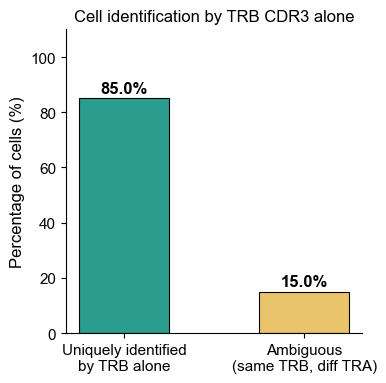

In [16]:
# ── Figure 1: Bar chart — cells uniquely vs ambiguously identified by TRB ──
fig, ax = plt.subplots(figsize=(4, 4))

labels = ['Uniquely identified\nby TRB alone', 'Ambiguous\n(same TRB, diff TRA)']
values = [pct_unique, pct_ambig]
colors = ['#2a9d8f', '#e9c46a']

bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Percentage of cells (%)')
ax.set_ylim(0, 110)
ax.set_title('Cell identification by TRB CDR3 alone')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'TRB_clonality_cells_bar.png', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'TRB_clonality_cells_bar.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'TRB_clonality_cells_bar.svg', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

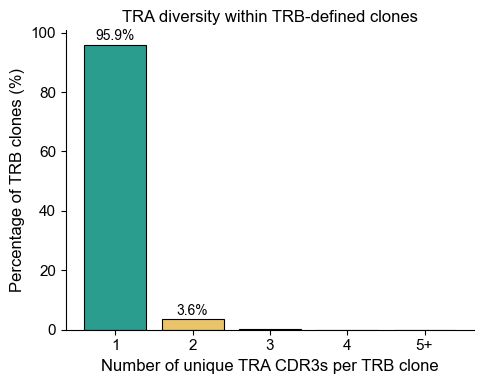

In [17]:
# ── Figure 2: Distribution of unique TRA count per TRB clone ──
# (shows most TRB clones have exactly 1 TRA)
fig, ax = plt.subplots(figsize=(5, 4))

vc = trb_clone_stats['n_unique_TRA'].value_counts().sort_index()
# Cap display at 5+
vc_plot = vc.copy()
vc_plot.index = [str(i) if i < 5 else '5+' for i in vc_plot.index]
vc_plot = vc_plot.groupby(level=0).sum()
order = [str(i) for i in range(1, 5)] + ['5+']
vc_plot = vc_plot.reindex(order, fill_value=0)

pct_plot = vc_plot / vc_plot.sum() * 100

bars = ax.bar(pct_plot.index, pct_plot.values,
              color=['#2a9d8f' if i == '1' else '#e9c46a' for i in pct_plot.index],
              edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, pct_plot.values):
    if val > 0.5:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Number of unique TRA CDR3s per TRB clone')
ax.set_ylabel('Percentage of TRB clones (%)')
ax.set_title('TRA diversity within TRB-defined clones')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'TRB_clonality_TRA_per_TRB_dist.png', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'TRB_clonality_TRA_per_TRB_dist.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'TRB_clonality_TRA_per_TRB_dist.svg', dpi=300, transparent=True, bbox_inches='tight')
plt.show()